In [ ]:
# Step 1: Import libraries
import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import scipy.stats as stats
from sqlalchemy import create_engine, types

In [131]:
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [132]:
# Step 1: Load the files
risk_df = pd.read_csv('..\data\hypertension_risk_factor_ratios.csv')
all_inner_merge_df = pd.read_csv('../data/analysis_data/dietary_demo_exam_quest_merged.csv')

In [133]:

# Step 3: Keep only the desired columns
columns_to_keep = ['Participant_ID', 'energy_intake', 'cholesterol_score',
                   'fat_quality_score','avg_sleep_hrs', 'Hypertensive']
merged_df = all_inner_merge_df [columns_to_keep]

In [134]:
merged_df

,Participant_ID,energy_intake,cholesterol_score,fat_quality_score,avg_sleep_hrs,Hypertensive
0,130378,1740.0,274.0,0.54,9.25,True
1,130379,2741.0,131.0,1.76,9.00,True
2,130380,1995.0,270.0,0.43,8.50,False
3,130386,2422.0,489.0,0.84,7.75,False
4,130387,3849.0,279.0,2.09,4.00,True
...,...,...,...,...,...,...
4981,142302,1267.0,61.0,0.50,9.00,True
4982,142303,280.0,7.0,0.93,9.00,False
4983,142307,1609.0,142.0,1.35,7.00,True
4984,142309,4651.0,402.0,0.45,10.00,True


In [135]:
# STEP 1: Load your merged dataset
df = merged_df.copy()  # Assuming you already merged nutrient + demographic data

# STEP 2: Ensure 'Hypertensive' is numeric (convert from bool)
df['Hypertensive'] = df['Hypertensive'].astype(int)
# Ensuring 'activity_level' is numeric (convert from string)
#df['activity_level'] = df['activity_level'].map({'Active': 1, 'Not Active': 0})

# STEP 3: Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# STEP 4: Drop ID column if it's not analytically useful
numeric_df = numeric_df.drop(columns=['Participant_ID'], errors='ignore')

# STEP 5: Compute correlation matrix
corr_matrix = numeric_df.corr()

# STEP 6: Focus on correlations with 'Hypertensive' only
hypertension_corr = corr_matrix[['Hypertensive']].sort_values(by='Hypertensive', ascending=False)



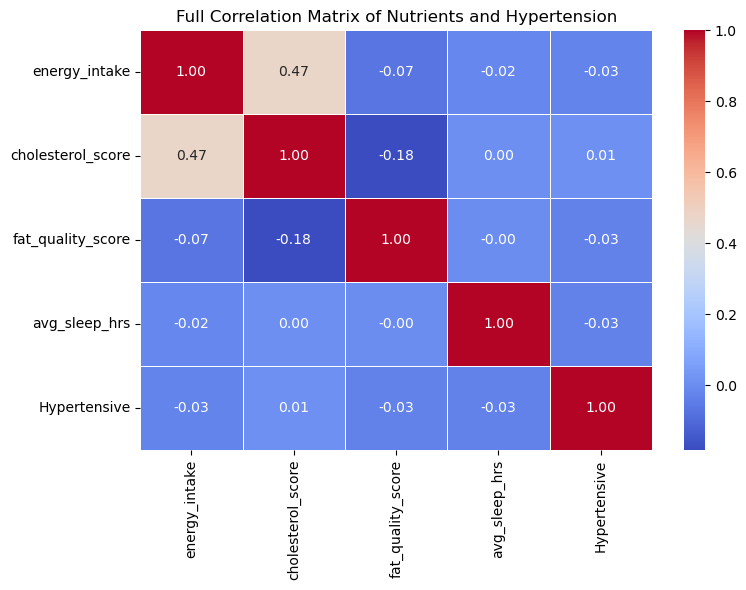

In [136]:
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Full Correlation Matrix of Nutrients and Hypertension")
plt.tight_layout()
plt.show()

In [149]:

# Step 3: Keep only the desired columns
columns_to_keep = ['Participant_ID','BMI','energy_intake','activity_level','Abdominal_Obesity',
                   'sed_minutes', 'Hypertensive']
df = all_inner_merge_df [columns_to_keep]
df['Abdominal_Obesity'] = df['Abdominal_Obesity'].astype(bool)

C:\Users\susan\AppData\Local\Temp\ipykernel_36640\3851717056.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Abdominal_Obesity'] = df['Abdominal_Obesity'].astype(bool)


C:\Users\susan\AppData\Local\Temp\ipykernel_36640\1485329353.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['activity_level'] = df['activity_level'].map({'Active': 1, 'Not Active': 0})
C:\Users\susan\AppData\Local\Temp\ipykernel_36640\1485329353.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Hypertensive'] = df['Hypertensive'].astype(int)
C:\Users\susan\AppData\Local\Temp\ipykernel_36640\1485329353.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFr

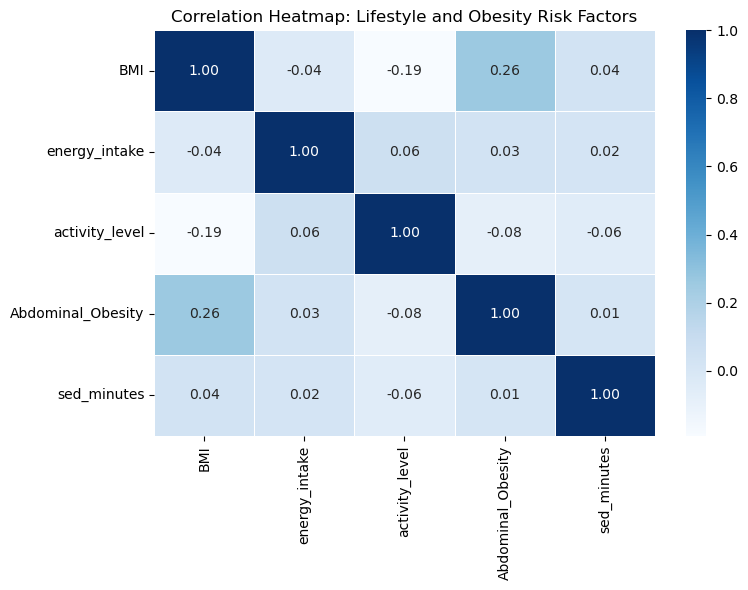

In [150]:
# Step 1: Map categorical strings to numeric values
df['activity_level'] = df['activity_level'].map({'Active': 1, 'Not Active': 0})

# Step 2: Map Abdominal_Obesity (if not already numeric)
df['Hypertensive'] = df['Hypertensive'].astype(int)
df['Abdominal_Obesity'] = df['Abdominal_Obesity'].astype(int)
  

# Step 3: Select relevant variables
selected_vars = df[['BMI', 'energy_intake', 'activity_level', 'Abdominal_Obesity', 'sed_minutes']]

# Step 4: Compute correlation matrix
corr_matrix = selected_vars.corr()

# Step 5: Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='Blues', fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap: Lifestyle and Obesity Risk Factors")
plt.tight_layout()
plt.show()

Composite Nutrient Quality Score

In [200]:
dietary_df = pd.read_csv('../data/dietary_data/dietary_nutrient_avg_data.csv')
demographic_df = pd.read_csv('../data/analysis_data/dietary_demo_exam_quest_merged.csv')

In [210]:
from sklearn.preprocessing import MinMaxScaler

# Step 1: Select relevant nutrient columns
positive_nutrients = [
    'dietary_fiber_gms', 'protein_gms', 'poly_unsaturated_fats_gms',
    'mono_saturated_fats_gms', 'potassium_mg', 'vitaminD_mcg',
    'vitaminC_mg', 'vitaK_mcg', 'calcium_mg'
]

negative_nutrients = [
    'saturated_fats_gms', 'cholestrol_gms', 'sodium_mg', 'total_sugars_gms'
]

all_nutrients = positive_nutrients + negative_nutrients

# Step 2: Drop rows with missing values for selected nutrients
df_nutrient = dietary_df[all_nutrients].fillna(0).copy()

# Step 3: Normalize using MinMaxScaler
scaler = MinMaxScaler()
normalized = pd.DataFrame(scaler.fit_transform(df_nutrient), columns=all_nutrients)

# Step 4: Invert the negative nutrient scores for unhealthy nutrients
for col in negative_nutrients:
    normalized[col] = 1 - normalized[col]

# Step 5: Calculate the composite nutrient score
dietary_df['nutrient_score'] = normalized.mean(axis=1)



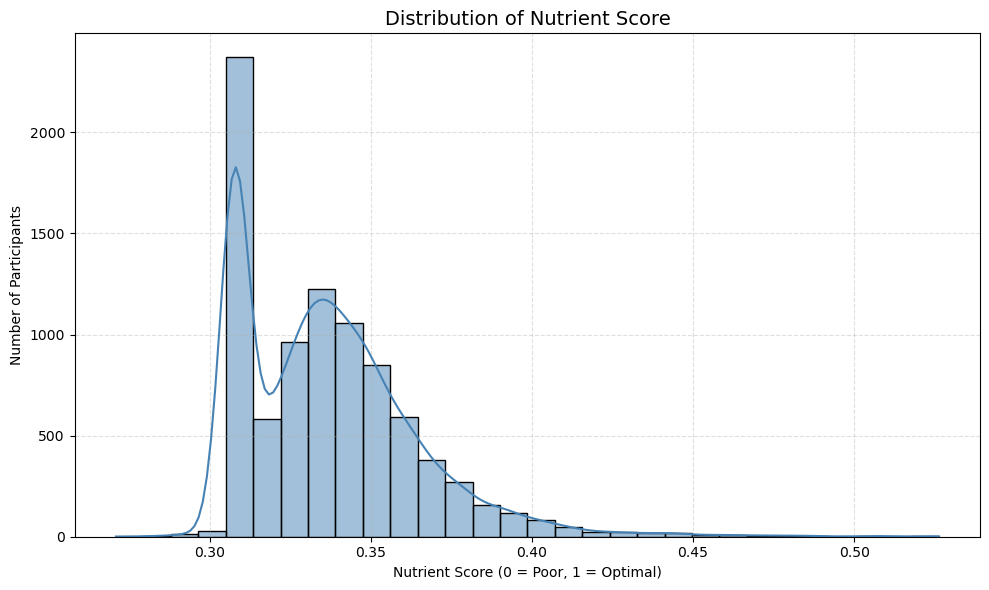

In [209]:

plt.figure(figsize=(10, 6))
sns.histplot(dietary_df['nutrient_score'], bins=30, kde=True, color='steelblue')
plt.title("Distribution of Nutrient Score", fontsize=14)
plt.xlabel("Nutrient Score (0 = Poor, 1 = Optimal)")
plt.ylabel("Number of Participants")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

count    8860.000000
mean        0.336713
std         0.027514
min         0.270928
25%         0.307692
50%         0.333638
75%         0.351094
max         0.526283
Name: nutrient_score, dtype: float64


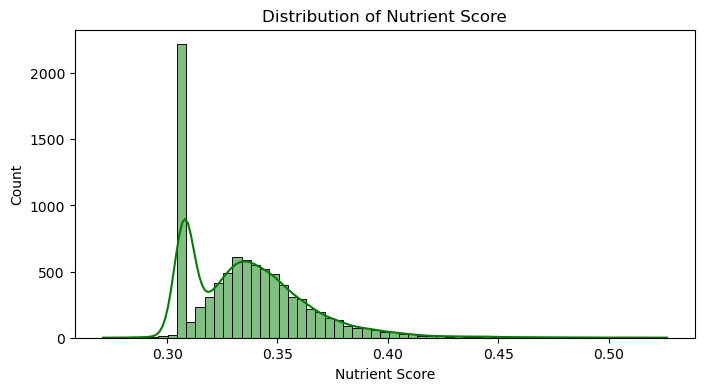

In [215]:
# Basic summary stats
print(dietary_df['nutrient_score'].describe())

# Visualize distribution
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(dietary_df['nutrient_score'], kde=True, color='green')
plt.title("Distribution of Nutrient Score")
plt.xlabel("Nutrient Score")
plt.ylabel("Count")
plt.show()

In [ ]:
dietary_df

In [273]:
# Merge with demographic info containing 'Hypertensive'
demographic_df = demographic_df.rename(columns={'Participant_ID':'seqn_no'})
analysis_df = pd.merge(dietary_df, demographic_df, on='seqn_no', how='inner')

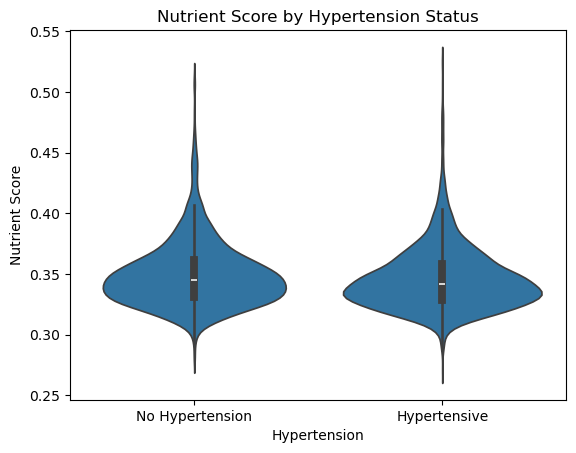

In [274]:
sns.violinplot(data=analysis_df, x='Hypertensive', y='nutrient_score')
plt.title("Nutrient Score by Hypertension Status")
plt.xticks([0, 1], ['No Hypertension', 'Hypertensive'])
plt.xlabel("Hypertension")
plt.ylabel("Nutrient Score")
plt.show()

In [ ]:
# Fill missing BMI with mean (or use median)
analysis_df['BMI'] = analysis_df['BMI'].fillna(analysis_df['BMI'].mean())

# Apply the map to the 'activity_level' column of your DataFrame
# Strip spaces and make lowercase
analysis_df['activity_level'] = analysis_df['activity_level'].str.strip().str.lower()
# Map to binary
analysis_df['activity_level'] = analysis_df['activity_level'].map({'active': 1, 'not active': 0})
analysis_df['Hypertensive'] = analysis_df['Hypertensive'].astype(int)

# Now, your 'features' list just holds the column names,which represents the predictive scores
features = ['nutrient_score', 'Age', 'BMI', 'activity_level']


X = analysis_df[features]
X = sm.add_constant(X)  # Adds intercept
y = analysis_df['Hypertensive']
print(X,y)
model = sm.Logit(y, X).fit()
print(model.summary())

In [280]:
# Force all columns to numeric (especially for categorical encoding)
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Combine X and y to clean missing rows at once
full_df = pd.concat([X, y], axis=1).dropna()

# Redefine X and y after dropping rows
X = full_df.drop(columns='Hypertensive')
y = full_df['Hypertensive']


# Logistic Regression
X = sm.add_constant(X)
logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.573292
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:           Hypertensive   No. Observations:                 4986
Model:                          Logit   Df Residuals:                     4981
Method:                           MLE   Df Model:                            4
Date:                Mon, 16 Jun 2025   Pseudo R-squ.:                  0.1678
Time:                        19:35:53   Log-Likelihood:                -2858.4
converged:                       True   LL-Null:                       -3434.6
Covariance Type:            nonrobust   LLR p-value:                3.444e-248
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -3.1459      0.469     -6.704      0.000      -4.066      -2.226
nutrient_score   

In [290]:
# Step 1: Get predicted probabilities
df_predict = pd.DataFrame(model.predict(X))

In [288]:
model.predict(X)

0       0.368500
1       0.720641
2       0.427189
3       0.306379
4       0.841500
          ...   
4981    0.640175
4982    0.719920
4983    0.473602
4984    0.274810
4985    0.828698
Length: 4986, dtype: float64

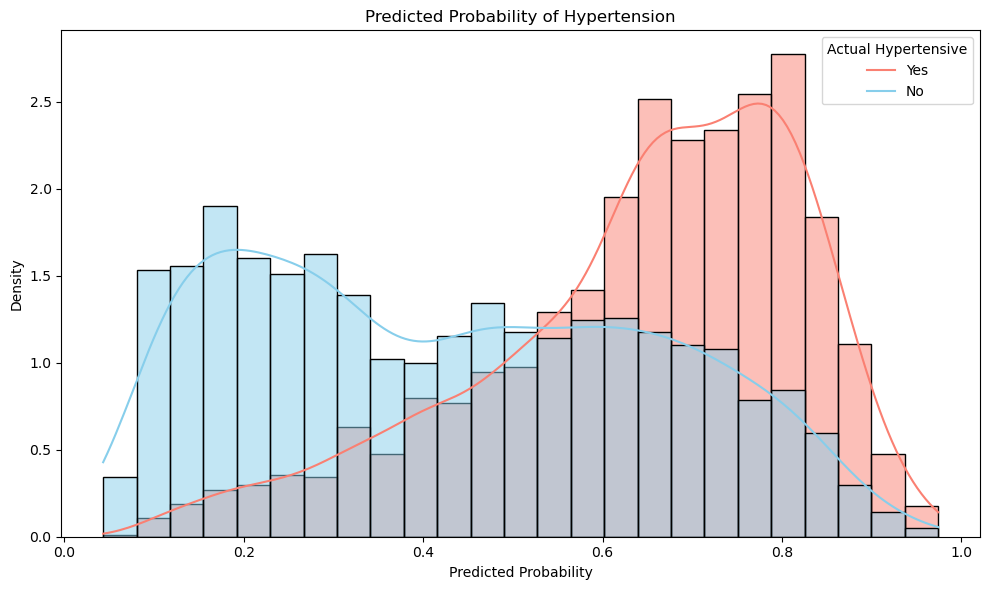

In [297]:
# Step 1: Get predicted probabilities
analysis_df['predicted_prob'] = model.predict(X)

# Step 2: Plot histogram of predicted probabilities grouped by actual hypertension status
plt.figure(figsize=(10, 6))
sns.histplot(
    data=analysis_df,
    x='predicted_prob',
    hue='Hypertensive',
    bins=25,
    kde=True,
    stat='density',
    common_norm=False,
    palette={0: 'skyblue', 1: 'salmon'}
)

plt.title('Predicted Probability of Hypertension')
plt.xlabel('Predicted Probability')
plt.ylabel('Density')
plt.legend(title='Actual Hypertensive', labels=['Yes', 'No'])
plt.tight_layout()
plt.show()

*The predicted probabilities visualized are entirely based on the features provided in the list:*

**features = ['nutrient_score', 'Age', 'BMI', 'activity_level']**

The X-axis represents the predicted probability of being hypertensive (from 0 to 1).
The Y-axis shows the density (relative frequency).


Two KDE-smoothed histograms (density curves) are plotted:
Red: People who are actually hypertensive (Hypertensive = 1)
Blue: People who are not hypertensive (Hypertensive = 0)

Non-hypertensive individuals cluster toward lower predicted probabilities (left side).
Hypertensive individuals tend to have higher predicted probabilities (right side).

This suggests your model is learning useful patterns: it's more likely to assign higher hypertension probabilities to actual hypertensive individuals.

In [298]:
analysis_df

,seqn_no,energy_kcal,protein_gms,carbohydrate_gms,total_sugars_gms,dietary_fiber_gms,total_fats_gms,saturated_fats_gms,mono_saturated_fats_gms,poly_unsaturated_fats_gms,...,fat_quality_score,cholesterol_score,energy_intake,vitaminD_IU,avg_sleep_hrs,sed_minutes,moderate_activity_minutes_per_week,vigorous_activity_minutes_per_week,activity_level,predicted_prob
0,130378,1740.0,80.46,169.66,43.71,10.1,55.07,21.000,17.040,11.401,...,0.54,274.0,1740.0,8.0,9.25,360.0,135.0,135.0,1,0.368500
1,130379,2741.0,86.45,314.86,113.58,29.6,67.18,14.544,19.386,25.622,...,1.76,131.0,2741.0,16.0,9.00,480.0,180.0,135.0,1,0.720641
2,130380,1995.0,69.86,281.67,114.66,21.1,65.38,26.936,18.638,11.687,...,0.43,270.0,1995.0,216.0,8.50,240.0,20.0,0.0,0,0.427189
3,130386,2422.0,132.41,207.53,37.89,25.1,116.54,33.935,46.022,28.569,...,0.84,489.0,2422.0,64.0,7.75,180.0,30.0,7.5,0,0.306379
4,130387,3849.0,68.93,376.54,227.99,22.0,234.39,49.849,63.889,104.428,...,2.09,279.0,3849.0,48.0,4.00,1200.0,0.0,0.0,0,0.841500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4981,142302,1267.0,27.97,219.74,129.70,5.7,31.80,10.951,11.298,5.527,...,0.50,61.0,1267.0,24.0,9.00,120.0,315.0,140.0,1,0.640175
4982,142303,280.0,7.79,39.52,15.15,4.2,10.15,2.969,3.087,2.754,...,0.93,7.0,280.0,72.0,9.00,360.0,840.0,0.0,1,0.719920
4983,142307,1609.0,71.49,194.91,90.41,16.7,61.66,13.885,25.144,18.735,...,1.35,142.0,1609.0,320.0,7.00,480.0,45.0,0.0,0,0.473602
4984,142309,4651.0,206.87,531.11,102.17,36.0,189.47,80.654,54.177,35.914,...,0.45,402.0,4651.0,40.0,10.00,240.0,210.0,0.0,1,0.274810


In [300]:


# Clean up activity_level column
analysis_df['activity_level'] = analysis_df['activity_level'].astype(str).str.strip().str.lower()
analysis_df['activity_level'] = analysis_df['activity_level'].map({'active': 1, 'not active': 0})

# Handle BMI and hypertension conversion
analysis_df['BMI'] = analysis_df['BMI'].fillna(analysis_df['BMI'].mean())
analysis_df['Hypertensive'] = analysis_df['Hypertensive'].astype(int)

# Create age groups
analysis_df['age_group'] = pd.cut(
    analysis_df['Age'],
    bins=[18, 30, 45, 60, 75, 90],
    labels=['18-29', '30-44', '45-59', '60-74', '75+']
)

# Scatter plot: Nutrient Score vs Sedentary Minutes with gender and hypertensive as hue and style
plt.figure(figsize=(14, 10))
sns.scatterplot(
    data=analysis_df,
    x='nutrient_score',
    y='sed_minutes',
    hue='gender',
    style='Hypertensive',
    size='sleep_hours',
    sizes=(20, 200),
    alpha=0.6
)
plt.title("Hypertension Risk Factors: Nutrient Score vs Sedentary Minutes (Hue: Gender, Style: Hypertensive)")
plt.xlabel("Nutrient Score")
plt.ylabel("Sedentary Minutes")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `gender` for `hue`. An entry with this name does not appear in `data`.

<Figure size 1400x1000 with 0 Axes>